# Building a Mini GPT from Scratch

## Objective

The goal of this assignment is to implement a decoder-only GPT-style
Transformer from scratch using PyTorch. The model uses character-level
tokenization, manually implemented multi-head masked self-attention,
Transformer decoder blocks, and autoregressive text generation.

The model is trained on the Shakespeare dataset and evaluated using three
decoding strategies:

1. Greedy decoding
2. Temperature sampling
3. Top-k sampling

Built-in Transformer and MultiheadAttention modules are not used.

In [1]:
# ============================================================
# STEP 1: IMPORTS AND REPRODUCIBILITY
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import random
import matplotlib.pyplot as plt

# Reproducibility
SEED = 5996

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)
print("Random seed:", SEED)

PyTorch version: 2.11.0+cpu
Device: cpu
Random seed: 5996


In [5]:
# ============================================================
# STEP 2: LOAD SHAKESPEARE DATASET
# ============================================================

file_path = "/content/shakespeare.txt"

with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

print("Total number of characters:", len(text))

print("\nFirst 500 characters:")
print("-" * 60)
print(text[:500])

Total number of characters: 1738

First 500 characters:
------------------------------------------------------------
ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the envious moon,
Who is already sick and pale with grief,
That thou her maid art far more fair than she.
Be not her maid, since she is envious;
Her vestal livery is but sick and green,
And none but fools do wear it; cast it off.
It is my lady, O, it is my love!
O, that she knew she were!
She speaks yet she says nothing: what of that?
Her eye discourses; I will answer it.
I


## Part 1.1 — Character-Level Tokenization

The Shakespeare corpus is tokenized at the character level. Each unique
character is treated as one token. Two dictionaries are constructed:

- `char_to_idx`: maps each character to an integer token ID.
- `idx_to_char`: maps each integer token ID back to its character.

Character-level tokenization keeps the vocabulary small and allows the model
to generate arbitrary words without requiring a predefined word vocabulary.

In [6]:
# ============================================================
# STEP 3: CHARACTER-LEVEL TOKENIZATION
# ============================================================

# Find all unique characters
chars = sorted(list(set(text)))

vocab_size = len(chars)

# Character -> integer
char_to_idx = {
    ch: i for i, ch in enumerate(chars)
}

# Integer -> character
idx_to_char = {
    i: ch for i, ch in enumerate(chars)
}

print("Vocabulary size:", vocab_size)

print("\nFirst 20 character mappings:")
for ch in chars[:20]:
    print(repr(ch), "->", char_to_idx[ch])

Vocabulary size: 49

First 20 character mappings:
'\n' -> 0
' ' -> 1
'!' -> 2
',' -> 3
'.' -> 4
':' -> 5
';' -> 6
'?' -> 7
'A' -> 8
'B' -> 9
'C' -> 10
'D' -> 11
'E' -> 12
'H' -> 13
'I' -> 14
'J' -> 15
'L' -> 16
'M' -> 17
'N' -> 18
'O' -> 19


In [7]:
# Convert text into token IDs
def encode(s):
    return [char_to_idx[ch] for ch in s]


# Convert token IDs back into text
def decode(indices):
    return "".join(idx_to_char[int(i)] for i in indices)


# Test tokenizer
example = "ROMEO:"

encoded_example = encode(example)
decoded_example = decode(encoded_example)

print("Original :", example)
print("Encoded  :", encoded_example)
print("Decoded  :", decoded_example)

Original : ROMEO:
Encoded  : [20, 19, 17, 12, 19, 5]
Decoded  : ROMEO:


In [8]:
# ============================================================
# STEP 4: ENCODE FULL DATASET
# ============================================================

data = torch.tensor(
    encode(text),
    dtype=torch.long
)

print("Token tensor shape:", data.shape)
print("Number of tokens:", len(data))

print("\nFirst 100 decoded tokens:")
print(decode(data[:100].tolist()))

Token tensor shape: torch.Size([1738])
Number of tokens: 1738

First 100 decoded tokens:
ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Ar


In [9]:
# ============================================================
# STEP 5: TRAIN / VALIDATION SPLIT
# ============================================================

split_idx = int(0.9 * len(data))

train_data = data[:split_idx]
val_data = data[split_idx:]

print("Training tokens   :", len(train_data))
print("Validation tokens :", len(val_data))

print(
    "Training percentage:",
    round(100 * len(train_data) / len(data), 2),
    "%"
)

Training tokens   : 1564
Validation tokens : 174
Training percentage: 89.99 %


## Part 1.2 — Sliding Window Dataset

A sequence length of 128 is used. Each training input contains 128 consecutive
character tokens, while its target contains the same sequence shifted one
position to the right.

Therefore, for an input sequence

`[t0, t1, ..., t127]`

the corresponding target is

`[t1, t2, ..., t128]`.

This trains the GPT model to predict the next character at every position.

In [10]:
# ============================================================
# STEP 6: SLIDING WINDOW DATASET
# ============================================================

SEQ_LEN = 128


class ShakespeareDataset(torch.utils.data.Dataset):

    def __init__(self, token_data, seq_len=128):
        self.data = token_data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):

        # Input: t ... t+127
        x = self.data[
            idx : idx + self.seq_len
        ]

        # Target: t+1 ... t+128
        y = self.data[
            idx + 1 : idx + self.seq_len + 1
        ]

        return x, y


train_dataset = ShakespeareDataset(
    train_data,
    SEQ_LEN
)

val_dataset = ShakespeareDataset(
    val_data,
    SEQ_LEN
)

print("Number of training sequences:", len(train_dataset))
print("Number of validation sequences:", len(val_dataset))

Number of training sequences: 1436
Number of validation sequences: 46


In [11]:
# ============================================================
# STEP 7: DISPLAY TWO INPUT-TARGET PAIRS
# ============================================================

for example_idx in [0, 128]:

    x, y = train_dataset[example_idx]

    print("=" * 80)
    print("EXAMPLE", example_idx)
    print("=" * 80)

    print("\nINPUT:")
    print(repr(decode(x.tolist())))

    print("\nTARGET:")
    print(repr(decode(y.tolist())))

    print()

EXAMPLE 0

INPUT:
'ROMEO:\nBut, soft! what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the '

TARGET:
'OMEO:\nBut, soft! what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the e'

EXAMPLE 128

INPUT:
'envious moon,\nWho is already sick and pale with grief,\nThat thou her maid art far more fair than she.\nBe not her maid, since she'

TARGET:
'nvious moon,\nWho is already sick and pale with grief,\nThat thou her maid art far more fair than she.\nBe not her maid, since she '



# Part 2 — GPT Architecture

## 2.1 Multi-Head Masked Self-Attention

The GPT model uses causal self-attention so that each token can attend only
to itself and previous tokens. It cannot access future tokens.

Queries, keys, and values are computed using separate linear projections.
They are then divided into multiple attention heads. Scaled dot-product
attention is computed independently for each head.

A lower-triangular causal mask is applied before softmax to prevent
attention to future positions.

This implementation uses four attention heads and does not use
`nn.MultiheadAttention`.

In [12]:
# ============================================================
# STEP 8: MANUAL MULTI-HEAD MASKED SELF-ATTENTION
# ============================================================

class MultiHeadMaskedSelfAttention(nn.Module):

    def __init__(self, hidden_dim, num_heads, max_seq_len):

        super().__init__()

        # hidden_dim must divide evenly across the heads
        assert hidden_dim % num_heads == 0

        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads

        # Manual Q, K, V projections
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)

        # Projection after concatenating all attention heads
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)

        # Lower triangular causal mask
        mask = torch.tril(
            torch.ones(max_seq_len, max_seq_len)
        )

        self.register_buffer(
            "causal_mask",
            mask.view(1, 1, max_seq_len, max_seq_len)
        )

    def forward(self, x):

        # x shape:
        # (batch_size, sequence_length, hidden_dim)

        B, T, C = x.shape

        # ----------------------------------------------------
        # Generate Q, K and V
        # ----------------------------------------------------

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # ----------------------------------------------------
        # Split hidden dimension into multiple heads
        #
        # (B, T, C)
        #      ->
        # (B, num_heads, T, head_dim)
        # ----------------------------------------------------

        Q = Q.view(
            B, T, self.num_heads, self.head_dim
        ).transpose(1, 2)

        K = K.view(
            B, T, self.num_heads, self.head_dim
        ).transpose(1, 2)

        V = V.view(
            B, T, self.num_heads, self.head_dim
        ).transpose(1, 2)

        # ----------------------------------------------------
        # Scaled dot-product attention
        # ----------------------------------------------------

        attention_scores = (
            Q @ K.transpose(-2, -1)
        ) / (self.head_dim ** 0.5)

        # ----------------------------------------------------
        # Causal masking
        #
        # Future positions receive -infinity so their
        # probability becomes zero after softmax.
        # ----------------------------------------------------

        mask = self.causal_mask[:, :, :T, :T]

        attention_scores = attention_scores.masked_fill(
            mask == 0,
            float("-inf")
        )

        # Convert scores to probabilities
        attention_weights = F.softmax(
            attention_scores,
            dim=-1
        )

        # ----------------------------------------------------
        # Weighted sum of values
        # ----------------------------------------------------

        attention_output = attention_weights @ V

        # ----------------------------------------------------
        # Concatenate all heads
        #
        # (B, heads, T, head_dim)
        #          ->
        # (B, T, hidden_dim)
        # ----------------------------------------------------

        attention_output = (
            attention_output
            .transpose(1, 2)
            .contiguous()
            .view(B, T, C)
        )

        # Final linear projection
        output = self.out_proj(attention_output)

        return output

In [13]:
# ============================================================
# STEP 9: TEST MULTI-HEAD ATTENTION
# ============================================================

HIDDEN_DIM = 128
NUM_HEADS = 4
SEQ_LEN = 128

attention_test = MultiHeadMaskedSelfAttention(
    hidden_dim=HIDDEN_DIM,
    num_heads=NUM_HEADS,
    max_seq_len=SEQ_LEN
).to(device)

# Fake batch:
# batch size = 2
# sequence length = 128
# hidden dimension = 128

x_test = torch.randn(
    2,
    SEQ_LEN,
    HIDDEN_DIM,
    device=device
)

with torch.no_grad():
    attention_output = attention_test(x_test)

print("=== MULTI-HEAD ATTENTION TEST ===")
print("Input shape :", x_test.shape)
print("Output shape:", attention_output.shape)

print("\nHidden dimension:", HIDDEN_DIM)
print("Number of heads :", NUM_HEADS)
print("Dimension/head  :", HIDDEN_DIM // NUM_HEADS)

=== MULTI-HEAD ATTENTION TEST ===
Input shape : torch.Size([2, 128, 128])
Output shape: torch.Size([2, 128, 128])

Hidden dimension: 128
Number of heads : 4
Dimension/head  : 32


In [14]:
# ============================================================
# STEP 10: VERIFY CAUSAL MASK
# ============================================================

print("First 10 x 10 section of causal mask:\n")

print(
    attention_test.causal_mask[
        0, 0, :10, :10
    ].cpu().numpy()
)

First 10 x 10 section of causal mask:

[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


## 2.2 Transformer Decoder Block

Each decoder block contains two main sublayers:

1. Multi-head masked self-attention
2. Position-wise feedforward neural network

Residual connections and Layer Normalization are applied around both
sublayers. The feedforward network uses a Linear → GELU → Linear
architecture.

The causal self-attention mechanism ensures that each position can only
use information from the current and previous tokens.

In [15]:
# ============================================================
# STEP 11: TRANSFORMER DECODER BLOCK
# ============================================================

class TransformerDecoderBlock(nn.Module):

    def __init__(
        self,
        hidden_dim,
        num_heads,
        max_seq_len,
        ff_dim
    ):
        super().__init__()

        # Multi-head masked self-attention
        self.attention = MultiHeadMaskedSelfAttention(
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            max_seq_len=max_seq_len
        )

        # First LayerNorm
        self.ln1 = nn.LayerNorm(hidden_dim)

        # Feedforward network
        self.feedforward = nn.Sequential(
            nn.Linear(hidden_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, hidden_dim)
        )

        # Second LayerNorm
        self.ln2 = nn.LayerNorm(hidden_dim)

    def forward(self, x):

        # --------------------------------------------
        # Masked self-attention + residual connection
        # --------------------------------------------
        attention_output = self.attention(x)

        x = self.ln1(
            x + attention_output
        )

        # --------------------------------------------
        # Feedforward network + residual connection
        # --------------------------------------------
        ff_output = self.feedforward(x)

        x = self.ln2(
            x + ff_output
        )

        return x

In [16]:
# ============================================================
# STEP 12: TEST TRANSFORMER DECODER BLOCK
# ============================================================

FF_DIM = 512

decoder_test = TransformerDecoderBlock(
    hidden_dim=HIDDEN_DIM,
    num_heads=NUM_HEADS,
    max_seq_len=SEQ_LEN,
    ff_dim=FF_DIM
).to(device)

x_test = torch.randn(
    2,
    SEQ_LEN,
    HIDDEN_DIM,
    device=device
)

with torch.no_grad():
    decoder_output = decoder_test(x_test)

print("=== DECODER BLOCK TEST ===")

print("Input shape :", x_test.shape)
print("Output shape:", decoder_output.shape)

print("\nHidden dimension     :", HIDDEN_DIM)
print("Attention heads      :", NUM_HEADS)
print("Feedforward dimension:", FF_DIM)

=== DECODER BLOCK TEST ===
Input shape : torch.Size([2, 128, 128])
Output shape: torch.Size([2, 128, 128])

Hidden dimension     : 128
Attention heads      : 4
Feedforward dimension: 512


## 2.3 Mini GPT Model

The complete GPT model consists of:

- Character token embeddings
- Learnable positional embeddings
- A stack of Transformer decoder blocks
- Final Layer Normalization
- Linear vocabulary projection

Two decoder blocks are used. The model receives token IDs with shape
`(batch_size, sequence_length)` and produces logits with shape
`(batch_size, sequence_length, vocabulary_size)`.

In [17]:
# ============================================================
# STEP 13: COMPLETE MINI GPT MODEL
# ============================================================

class MiniGPT(nn.Module):

    def __init__(
        self,
        vocab_size,
        hidden_dim=128,
        num_heads=4,
        num_layers=2,
        max_seq_len=128,
        ff_dim=512
    ):
        super().__init__()

        self.max_seq_len = max_seq_len
        self.hidden_dim = hidden_dim

        # Character/token embedding
        self.token_embedding = nn.Embedding(
            vocab_size,
            hidden_dim
        )

        # Learnable positional embedding
        self.position_embedding = nn.Embedding(
            max_seq_len,
            hidden_dim
        )

        # Stack of decoder blocks
        self.blocks = nn.ModuleList([
            TransformerDecoderBlock(
                hidden_dim=hidden_dim,
                num_heads=num_heads,
                max_seq_len=max_seq_len,
                ff_dim=ff_dim
            )
            for _ in range(num_layers)
        ])

        # Final LayerNorm
        self.final_ln = nn.LayerNorm(hidden_dim)

        # Project hidden states to vocabulary logits
        self.output_projection = nn.Linear(
            hidden_dim,
            vocab_size
        )

    def forward(self, token_ids):

        B, T = token_ids.shape

        if T > self.max_seq_len:
            raise ValueError(
                f"Sequence length {T} exceeds "
                f"maximum {self.max_seq_len}"
            )

        # Positions: 0, 1, ..., T-1
        positions = torch.arange(
            T,
            device=token_ids.device
        )

        # Token embeddings
        token_emb = self.token_embedding(token_ids)

        # Positional embeddings
        position_emb = self.position_embedding(positions)

        # Combine token + positional information
        x = token_emb + position_emb

        # Pass through decoder blocks
        for block in self.blocks:
            x = block(x)

        # Final normalization
        x = self.final_ln(x)

        # Convert hidden representations to vocabulary logits
        logits = self.output_projection(x)

        return logits

In [18]:
# ============================================================
# STEP 14: CREATE GPT MODEL
# ============================================================

NUM_LAYERS = 2

model = MiniGPT(
    vocab_size=vocab_size,
    hidden_dim=HIDDEN_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    max_seq_len=SEQ_LEN,
    ff_dim=FF_DIM
).to(device)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=== MINI GPT ARCHITECTURE ===")
print("Vocabulary size       :", vocab_size)
print("Hidden dimension      :", HIDDEN_DIM)
print("Number of heads       :", NUM_HEADS)
print("Number of layers      :", NUM_LAYERS)
print("Sequence length       :", SEQ_LEN)
print("Feedforward dimension :", FF_DIM)
print("Total parameters      :", f"{total_params:,}")
print("Trainable parameters  :", f"{trainable_params:,}")

=== MINI GPT ARCHITECTURE ===
Vocabulary size       : 49
Hidden dimension      : 128
Number of heads       : 4
Number of layers      : 2
Sequence length       : 128
Feedforward dimension : 512
Total parameters      : 425,777
Trainable parameters  : 425,777


In [19]:
# ============================================================
# STEP 15: TEST GPT ON REAL SHAKESPEARE DATA
# ============================================================

x_sample, y_sample = train_dataset[0]

# Add batch dimension
x_sample = x_sample.unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(x_sample)

print("=== GPT FORWARD PASS TEST ===")
print("Input shape :", x_sample.shape)
print("Logits shape:", logits.shape)

print("\nExpected logits shape:")
print(
    f"(1, {SEQ_LEN}, {vocab_size})"
)

=== GPT FORWARD PASS TEST ===
Input shape : torch.Size([1, 128])
Logits shape: torch.Size([1, 128, 49])

Expected logits shape:
(1, 128, 49)


# Part 3 — Training

The Mini GPT model is trained using the Adam optimizer and cross-entropy
loss. Cross-entropy is appropriate because next-character prediction is a
multi-class classification problem over the character vocabulary.

The model is trained for 5 epochs. Training loss is recorded after every
epoch to evaluate convergence.

In [20]:
# ============================================================
# STEP 16: CREATE DATALOADERS
# ============================================================

from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

# Inspect one batch
x_batch, y_batch = next(iter(train_loader))

print("\nInput batch shape :", x_batch.shape)
print("Target batch shape:", y_batch.shape)

Batch size: 64
Training batches: 22
Validation batches: 1

Input batch shape : torch.Size([64, 128])
Target batch shape: torch.Size([64, 128])


In [21]:
# ============================================================
# STEP 17: OPTIMIZER AND LOSS
# ============================================================

LEARNING_RATE = 3e-4
NUM_EPOCHS = 5

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

criterion = nn.CrossEntropyLoss()

print("Optimizer     : Adam")
print("Learning rate :", LEARNING_RATE)
print("Epochs        :", NUM_EPOCHS)
print("Loss function : CrossEntropyLoss")

Optimizer     : Adam
Learning rate : 0.0003
Epochs        : 5
Loss function : CrossEntropyLoss


In [22]:
# ============================================================
# STEP 18: TRAIN MINI GPT
# ============================================================

train_losses = []

model.train()

for epoch in range(NUM_EPOCHS):

    total_loss = 0.0

    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(x_batch)

        # logits: (B, T, vocab_size)
        # targets: (B, T)
        #
        # CrossEntropyLoss expects:
        # predictions -> (N, classes)
        # targets     -> (N)

        loss = criterion(
            logits.reshape(-1, vocab_size),
            y_batch.reshape(-1)
        )

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        total_loss += loss.item()

        # Occasional progress
        if (batch_idx + 1) % 100 == 0:
            print(
                f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
                f"Batch {batch_idx + 1}/{len(train_loader)} | "
                f"Loss: {loss.item():.4f}"
            )

    average_loss = total_loss / len(train_loader)

    train_losses.append(average_loss)

    print(
        f"\nEpoch {epoch + 1}/{NUM_EPOCHS} "
        f"completed | Average Training Loss: "
        f"{average_loss:.4f}\n"
    )


Epoch 1/5 completed | Average Training Loss: 3.3937


Epoch 2/5 completed | Average Training Loss: 2.8129


Epoch 3/5 completed | Average Training Loss: 2.5608


Epoch 4/5 completed | Average Training Loss: 2.3909


Epoch 5/5 completed | Average Training Loss: 2.2806



In [23]:
# ============================================================
# STEP 19: TRAINING SUMMARY
# ============================================================

print("=== TRAINING RESULTS ===")

for epoch, loss in enumerate(train_losses, start=1):
    print(
        f"Epoch {epoch}: "
        f"Average Loss = {loss:.4f}"
    )

print(
    "\nInitial epoch loss:",
    f"{train_losses[0]:.4f}"
)

print(
    "Final epoch loss:",
    f"{train_losses[-1]:.4f}"
)

improvement = train_losses[0] - train_losses[-1]

print(
    "Loss reduction:",
    f"{improvement:.4f}"
)

=== TRAINING RESULTS ===
Epoch 1: Average Loss = 3.3937
Epoch 2: Average Loss = 2.8129
Epoch 3: Average Loss = 2.5608
Epoch 4: Average Loss = 2.3909
Epoch 5: Average Loss = 2.2806

Initial epoch loss: 3.3937
Final epoch loss: 2.2806
Loss reduction: 1.1131


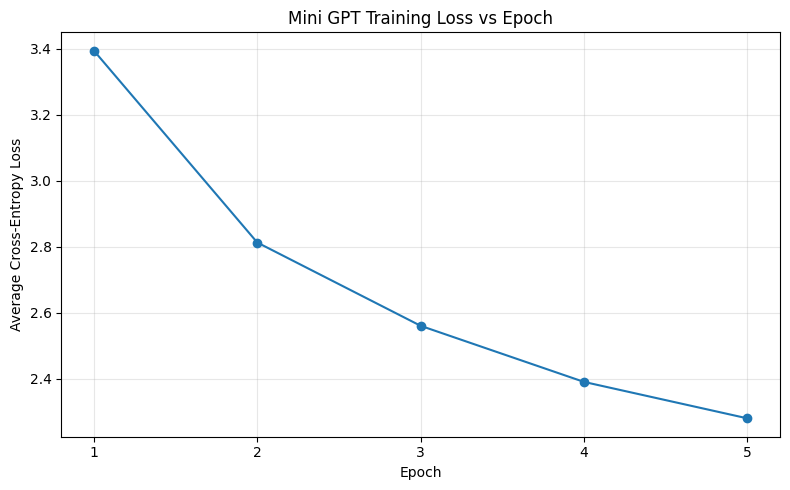

In [24]:
# ============================================================
# STEP 20: TRAINING LOSS PLOT
# ============================================================

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Average Cross-Entropy Loss")
plt.title("Mini GPT Training Loss vs Epoch")
plt.xticks(list(epochs))
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "mini_gpt_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Part 4 — Text Generation and Sampling

The trained Mini GPT is evaluated using the prompt **"ROMEO:"**.

Three decoding strategies are compared:

1. **Greedy decoding** — always selects the character with the highest probability.
2. **Temperature sampling** — modifies the probability distribution before sampling. Lower temperatures make generation more deterministic, while higher temperatures increase diversity.
3. **Top-k sampling** — restricts sampling to the k most probable next characters.

All methods use the same trained model for a fair comparison.

In [25]:
# ============================================================
# STEP 22: GREEDY DECODING
# ============================================================

@torch.no_grad()
def generate_greedy(model, prompt, max_new_chars=300):

    model.eval()

    # Convert prompt characters to token IDs
    tokens = [char_to_idx[ch] for ch in prompt]

    generated = tokens.copy()

    for _ in range(max_new_chars):

        # Only use the last SEQ_LEN tokens
        context = generated[-SEQ_LEN:]

        x = torch.tensor(
            context,
            dtype=torch.long,
            device=device
        ).unsqueeze(0)

        # Forward pass
        logits = model(x)

        # Get prediction for the final position
        next_token_logits = logits[0, -1, :]

        # Greedy = highest probability token
        next_token = torch.argmax(
            next_token_logits
        ).item()

        generated.append(next_token)

    return "".join(
        idx_to_char[i] for i in generated
    )


prompt = "ROMEO:"

greedy_text = generate_greedy(
    model,
    prompt,
    max_new_chars=300
)

print("=== GREEDY DECODING ===")
print(greedy_text)

=== GREEDY DECODING ===
ROMEO:
Ror the t the the the the the ar ar the the the the at the the the the athe the the the the t the the the the the the athe the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the 


In [26]:
# ============================================================
# STEP 23: TEMPERATURE SAMPLING
# ============================================================

@torch.no_grad()
def generate_temperature(
    model,
    prompt,
    temperature=1.0,
    max_new_chars=300
):

    model.eval()

    tokens = [char_to_idx[ch] for ch in prompt]
    generated = tokens.copy()

    for _ in range(max_new_chars):

        context = generated[-SEQ_LEN:]

        x = torch.tensor(
            context,
            dtype=torch.long,
            device=device
        ).unsqueeze(0)

        logits = model(x)

        next_token_logits = logits[0, -1, :]

        # Apply temperature
        next_token_logits = (
            next_token_logits / temperature
        )

        probabilities = torch.softmax(
            next_token_logits,
            dim=-1
        )

        # Sample from probability distribution
        next_token = torch.multinomial(
            probabilities,
            num_samples=1
        ).item()

        generated.append(next_token)

    return "".join(
        idx_to_char[i] for i in generated
    )


temperatures = [0.5, 1.0, 1.5]

temperature_outputs = {}

for temp in temperatures:

    generated_text = generate_temperature(
        model,
        "ROMEO:",
        temperature=temp,
        max_new_chars=300
    )

    temperature_outputs[temp] = generated_text

    print("\n" + "=" * 70)
    print(f"TEMPERATURE = {temp}")
    print("=" * 70)

    print(generated_text)


TEMPERATURE = 0.5
ROMEO:
And, be t the all t I athatin nathee whe inor f tha thor ar the the her t me t isher t t mer t at I the ndathe t is t hor the l nor o t n ar win but t alllllld the it fal s I nel cakllllllll bendor menond ather nother t all athotheanothe beathal ne anor thathale, s the s anof mer inor Ro ishel thil

TEMPERATURE = 1.0
ROMEO:
I smillfar ar hrswevenathwiny t R?
Hezerther is f wAzengornNa!
Son thandhs t lt t tid s bee r O;
Shace ar mywkengu owise.
T:
Momore?eatme n iswo
Shothe il Romenor woCETaullo st thes ill
IaRo Ry d mef isrseatlr whabe as willlll wo w.
Romomythakef athalf ns;
’

Thas nd, b ishals n outhaor mmefeld sh 

TEMPERATURE = 1.5
ROMEO:
OUJUlloL
Ce. o?’s ?
W kwhpusmy phomo wSU:NoT:,zheand they!Aond;st p:;
Henzhy’t nt’AfJLCshonisbed tut’a Uo!

Toro;orn ield,?
Hesar
A whed.RE;
I oWho n
unhererC so

ndm in
A r!
AU:ei, to!
BAmM:LId,’omsnNi dUhreNold sdyUc: :
Noof,fe I ardrd de MWsstEk wishoof’iimWousokreslidaefMtlshemytf
Uovnt ! tf he


In [27]:
# ============================================================
# STEP 24: TOP-K SAMPLING
# ============================================================

@torch.no_grad()
def generate_top_k(
    model,
    prompt,
    k=10,
    max_new_chars=300
):

    model.eval()

    tokens = [char_to_idx[ch] for ch in prompt]
    generated = tokens.copy()

    for _ in range(max_new_chars):

        context = generated[-SEQ_LEN:]

        x = torch.tensor(
            context,
            dtype=torch.long,
            device=device
        ).unsqueeze(0)

        logits = model(x)

        next_token_logits = logits[0, -1, :]

        # Select k highest logits
        top_k_logits, top_k_indices = torch.topk(
            next_token_logits,
            k
        )

        # Convert selected logits into probabilities
        probabilities = torch.softmax(
            top_k_logits,
            dim=-1
        )

        # Sample within top-k candidates
        sampled_index = torch.multinomial(
            probabilities,
            num_samples=1
        )

        next_token = top_k_indices[
            sampled_index
        ].item()

        generated.append(next_token)

    return "".join(
        idx_to_char[i] for i in generated
    )


k_values = [5, 20]

top_k_outputs = {}

for k in k_values:

    generated_text = generate_top_k(
        model,
        "ROMEO:",
        k=k,
        max_new_chars=300
    )

    top_k_outputs[k] = generated_text

    print("\n" + "=" * 70)
    print(f"TOP-K = {k}")
    print("=" * 70)

    print(generated_text)


TOP-K = 5
ROMEO:
T:
He,e n thanome n s the aitaller stheat amen s athen t sh the ame t t ne meatinall thar t s s tat at alo anealld, no shenathar she thenonou nomatheswertarere t ne s tar nenor t ar shathicer wond al shanou art naicamy al t nonan anald shy tal no s all atho thal s atind sithes nd, wisher is allor t

TOP-K = 20
ROMEO:
O te, ant otit
Whhe he ondour met ks besio! Iher thy flt are khe, o is wy Ro and wel sw:
I Rothis, ar fofaIEEWh k t thoudanat l neaderyan o is hon, ther f m;
E
Ltf keren, eas,
Whe; larshy
Whe, at eren homy I’domo is thallou af had I s beany fallEThe lous torfof.
Hereatanathl pusir batil I
Awefast s


In [28]:
print("=== SAMPLING EXPERIMENT SUMMARY ===")

print("\nPrompt:")
print("ROMEO:")

print("\nMethods completed:")
print("1. Greedy decoding")
print("2. Temperature = 0.5")
print("3. Temperature = 1.0")
print("4. Temperature = 1.5")
print("5. Top-k = 5")
print("6. Top-k = 20")

=== SAMPLING EXPERIMENT SUMMARY ===

Prompt:
ROMEO:

Methods completed:
1. Greedy decoding
2. Temperature = 0.5
3. Temperature = 1.0
4. Temperature = 1.5
5. Top-k = 5
6. Top-k = 20


# Part 5 — Analysis of Decoding Techniques

In [29]:
print("=" * 70)
print("GREEDY DECODING")
print("=" * 70)
print(greedy_text)

for temp in [0.5, 1.0, 1.5]:
    print("\n" + "=" * 70)
    print(f"TEMPERATURE = {temp}")
    print("=" * 70)
    print(temperature_outputs[temp])

for k in [5, 20]:
    print("\n" + "=" * 70)
    print(f"TOP-K = {k}")
    print("=" * 70)
    print(top_k_outputs[k])

GREEDY DECODING
ROMEO:
Ror the t the the the the the ar ar the the the the at the the the the athe the the the the t the the the the the the athe the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the 

TEMPERATURE = 0.5
ROMEO:
And, be t the all t I athatin nathee whe inor f tha thor ar the the her t me t isher t t mer t at I the ndathe t is t hor the l nor o t n ar win but t alllllld the it fal s I nel cakllllllll bendor menond ather nother t all athotheanothe beathal ne anor thathale, s the s anof mer inor Ro ishel thil

TEMPERATURE = 1.0
ROMEO:
I smillfar ar hrswevenathwiny t R?
Hezerther is f wAzengornNa!
Son thandhs t lt t tid s bee r O;
Shace ar mywkengu owise.
T:
Momore?eatme n iswo
Shothe il Romenor woCETaullo st thes ill
IaRo Ry d mef isrseatlr whabe as willlll wo w.
Romomythakef athalf ns;
’

Thas nd, b ishals n outhaor mmefeld sh 

TEMPERATURE = 1.5
ROMEO:

# Part 5 — Analysis of Decoding Techniques

## Comparison of Decoding Methods

### Greedy Decoding

Greedy decoding always selects the character with the highest predicted probability at every generation step. In my experiment, greedy decoding produced highly repetitive text, repeatedly generating common fragments such as "the". This happens because there is no randomness in the selection process, so once the model enters a high-probability repetitive pattern, it can remain in that pattern. Therefore, greedy decoding was the least diverse method in this experiment.

### Temperature Sampling

Temperature sampling changes the sharpness of the probability distribution before sampling.

- **Temperature = 0.5:** The output was relatively conservative and contained many common character and word patterns. Because the probability distribution is sharpened, high-probability characters are strongly preferred.
- **Temperature = 1.0:** The generated text showed substantially more variation, including line breaks and structures resembling dialogue. However, many generated words were still incomplete or nonsensical.
- **Temperature = 1.5:** This produced the greatest variation among the tested temperatures. The output contained many unusual character combinations, punctuation marks, and word fragments. The increased randomness improved diversity but reduced coherence.

Thus, increasing temperature increased diversity while generally decreasing textual consistency.

### Top-k Sampling

Top-k sampling restricts generation to the k highest-probability next characters and then samples from those candidates.

With **k = 5**, generation was strongly constrained to likely characters. The resulting text contained repetitive patterns but avoided some of the extreme randomness observed with high-temperature sampling.

With **k = 20**, the model had a much larger set of possible characters to choose from. This increases potential diversity compared with k = 5, although it can also introduce less likely characters and reduce coherence.

## Overall Comparison

The experiments demonstrate the trade-off between coherence and diversity in decoding. Greedy decoding was the most deterministic but became highly repetitive. Lower temperature and small top-k values constrained generation and generally produced more predictable character patterns. Higher temperature allowed much greater variation, with **temperature = 1.5 producing the most visibly diverse output in these experiments**, but it also generated the most irregular text.

Overall, the model has learned character-level patterns from the training text, but the generated text is not consistently meaningful English. This is reasonable for a small character-level GPT trained for only five epochs. The training loss decreased from **3.3937 in epoch 1 to 2.2806 in epoch 5**, showing that the model learned from the training data even though generation quality remains limited.